# Dual Language-Specific Encoder Pairs — Adversarial Divergence Experiment

**Goal:** Break cross-lingual adversarial transfer by giving each language its own
encoder pair: per-language LoRA adapters inside every ViT block (image side) plus
per-language text projection heads (text side), trained with a three-term loss:

```
L = sum_l  CE(f_l(x) . g_l^T, y)                   (1) classification
  + lam_div  sum_{l!=l'} cos(f_l(x), f_{l'}(x))    (2) image divergence
  + lam_ret  sum_{l!=en} CE(f_l(x_adv) . g_l^T, y) (3) adversarial retention
```

**Key difference from prior experiments (A-F):** both image AND text sides are
language-specific simultaneously. Classification and divergence losses now reinforce
each other instead of fighting (shared text anchors previously re-centered images).

**Success criterion:** retention > 50% in at least 1 non-EN language at any epsilon.

In [2]:
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "open_clip_torch", "transformers", "datasets", "ftfy", "sentencepiece",
])
print("packages installed into:", sys.executable)

packages installed into: d:\ian\2026summer\.venv\Scripts\python.exe


In [3]:
import importlib, sys

import transformers  # must import BEFORE open_clip
print("transformers", transformers.__version__)

if "open_clip" in sys.modules:
    import open_clip.hf_model as _oc_hf
    if _oc_hf.transformers is None:
        for name in list(sys.modules):
            if name == "open_clip" or name.startswith("open_clip."):
                del sys.modules[name]
        importlib.invalidate_caches()

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, time
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import open_clip
import matplotlib.pyplot as plt

import open_clip.hf_model as _oc_hf
assert _oc_hf.transformers is not None, "restart kernel and re-run from top"

device = "cuda" if torch.cuda.is_available() else "cpu"
assert device == "cuda", "Enable a GPU runtime"
print("device:", torch.cuda.get_device_name(0))
torch.manual_seed(0); np.random.seed(0)

transformers 5.12.1
device: NVIDIA GeForce RTX 5070 Ti


In [4]:
DATASET      = "cifar10"
N_CLEAN      = 500
N_TRANSFER   = 300
EPS_LIST     = [0.5, 1, 2, 4, 8]
PGD_STEPS    = 20
BATCH        = 64
LANGS        = ["en", "ko", "es", "fr", "ja"]

# Dual-encoder hyperparameters
RANK           = 32       # LoRA rank (Exp C used 16 and collapsed at LR=1e-3)
LAM_DIV        = 1.0      # image-embedding divergence weight
LAM_RET        = 1.0      # adversarial retention weight
DUAL_LR        = 1e-4     # 10x lower than Exp C -- prevents collapse
DUAL_EPOCHS    = 15
DUAL_TRAIN_N   = 1000
DUAL_PGD_STEPS = 7        # fast inner loop
DUAL_TRAIN_EPS = 2 / 255  # training attack budget

print("config OK | dataset:", DATASET, "| rank:", RANK, "| lr:", DUAL_LR)

config OK | dataset: cifar10 | rank: 32 | lr: 0.0001


In [5]:
model, _, preprocess_val = open_clip.create_model_and_transforms(
    "xlm-roberta-base-ViT-B-32", pretrained="laion5b_s13b_b90k")
tokenizer = open_clip.get_tokenizer("xlm-roberta-base-ViT-B-32")
model = model.to(device).eval()
for p in model.parameters(): p.requires_grad_(False)

norm = [t for t in preprocess_val.transforms if isinstance(t, T.Normalize)][0]
MEAN = torch.tensor(norm.mean, device=device).view(1, 3, 1, 1)
STD  = torch.tensor(norm.std,  device=device).view(1, 3, 1, 1)
LOGIT_SCALE = model.logit_scale.exp().detach()

def encode_image(x_pixel):
    feats = model.encode_image((x_pixel - MEAN) / STD)
    return F.normalize(feats, dim=-1)

def logits_for(img_feats, txt_feats):
    return LOGIT_SCALE * img_feats @ txt_feats.t()

print("model loaded; logit_scale =", float(LOGIT_SCALE))

model loaded; logit_scale = 100.0


In [6]:
CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]
STL10_CLASSES   = ["airplane","bird","car","cat","deer",
                   "dog","horse","monkey","ship","truck"]

TRANSLATIONS = {
 "airplane":  {"en":"airplane","ko":"비행기","es":"avión","fr":"avion","ja":"飛行機"},
 "automobile":{"en":"automobile","ko":"자동차","es":"automóvil","fr":"automobile","ja":"自動車"},
 "car":       {"en":"car","ko":"자동차","es":"coche","fr":"voiture","ja":"車"},
 "bird":      {"en":"bird","ko":"새","es":"pájaro","fr":"oiseau","ja":"鳥"},
 "cat":       {"en":"cat","ko":"고양이","es":"gato","fr":"chat","ja":"猫"},
 "deer":      {"en":"deer","ko":"사슴","es":"ciervo","fr":"cerf","ja":"鹿"},
 "dog":       {"en":"dog","ko":"개","es":"perro","fr":"chien","ja":"犬"},
 "frog":      {"en":"frog","ko":"개구리","es":"rana","fr":"grenouille","ja":"カエル"},
 "horse":     {"en":"horse","ko":"말","es":"caballo","fr":"cheval","ja":"馬"},
 "monkey":    {"en":"monkey","ko":"원숭이","es":"mono","fr":"singe","ja":"猿"},
 "ship":      {"en":"ship","ko":"배","es":"barco","fr":"bateau","ja":"船"},
 "truck":     {"en":"truck","ko":"트럭","es":"camión","fr":"camion","ja":"トラック"},
}
TEMPLATES = {
    "en": "a photo of a {}.",
    "ko": "{}의 사진.",
    "es": "una foto de un {}.",
    "fr": "une photo d'un {}.",
    "ja": "{}の写真。"
}

@torch.no_grad()
def build_text_embeddings(classes):
    out = {}
    for l in LANGS:
        prompts = [TEMPLATES[l].format(TRANSLATIONS[c][l]) for c in classes]
        feats = model.encode_text(tokenizer(prompts).to(device))
        out[l] = F.normalize(feats, dim=-1)
    return out

print("translations + text-embedding builder ready")

translations + text-embedding builder ready


In [7]:
from datasets import load_dataset

pixel_tf = T.Compose([T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
                      T.CenterCrop(224), T.ToTensor()])
_CIFAR_HF = {}

class HFCifar10(torch.utils.data.Dataset):
    def __init__(self, hf_ds, transform):
        self.hf_ds, self.transform = hf_ds, transform
    def __len__(self): return len(self.hf_ds)
    def __getitem__(self, i):
        ex = self.hf_ds[i]
        img = ex["img"]
        if self.transform is not None:
            img = self.transform(img)
        return img, ex["label"]

def load_cifar10(split, transform):
    if split not in _CIFAR_HF:
        hf_split = "train" if split == "train" else "test"
        print(f"Loading CIFAR-10 {split} from HuggingFace...")
        _CIFAR_HF[split] = load_dataset("uoft-cs/cifar10", split=hf_split)
    return HFCifar10(_CIFAR_HF[split], transform)

NUM_WORKERS = 0 if sys.platform == "win32" else 2

def get_loader(n, batch_size=BATCH, seed=0, split="test"):
    if DATASET == "stl10":
        tv_split = "train" if split == "train" else "test"
        ds = torchvision.datasets.STL10("data", split=tv_split, download=True, transform=pixel_tf)
        classes = STL10_CLASSES
    else:
        ds = load_cifar10(split, pixel_tf)
        classes = CIFAR10_CLASSES
    if n < len(ds):
        idx = np.random.default_rng(seed).permutation(len(ds))[:n]
        ds = Subset(ds, idx.tolist())
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS), classes

loader, CLASSES = get_loader(N_CLEAN)
TXT = build_text_embeddings(CLASSES)
print("classes:", CLASSES)

Loading CIFAR-10 test from HuggingFace...
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
# ── Image side: per-language CLS-token LoRA at every ViT block ───────────────
#
# The ViT uses NLD layout [batch, seq, d] with batch_first=True throughout.
# CLS token: x[:, 0, :]   Injection: cat([cls_new.unsqueeze(1), x[:, 1:]], dim=1)
#
# CRITICAL FIX vs. Experiment C: Exp C manually permuted to LND (seq-first)
# before passing to resblocks. With batch_first=True the resblocks expect NLD,
# so Exp C's attention ran over batch items (seq=2) not tokens (seq=50) --
# semantically wrong, which contributed to training collapse.
# This implementation uses vit._embeds() which correctly returns NLD.

class IntermediateLoRA(nn.Module):
    def __init__(self, d=768, r=RANK):
        super().__init__()
        self.A = nn.Linear(d, r, bias=False)
        self.B = nn.Linear(r, d, bias=False)
        nn.init.kaiming_uniform_(self.A.weight)
        nn.init.zeros_(self.B.weight)  # zero-init B: starts as identity

    def forward(self, x):
        return x + self.B(self.A(x))

# 5 languages x 12 blocks = 60 adapters
ml_adapters = nn.ModuleDict({
    f"{lang}_{i}": IntermediateLoRA(d=768, r=RANK).to(device)
    for lang in LANGS for i in range(12)
})

# ── Text side: per-language projection heads ──────────────────────────────────
#
# model.text is HFTextEncoder with MeanPooler -> 768-d -> model.text.proj (Sequential)
# We bypass model.text.proj entirely and apply our own nn.Linear(768, 512) per lang.
# Gradient flows through lang_text_proj[lang]; backbone (XLM-R) stays frozen.

lang_text_proj = nn.ModuleDict({
    lang: nn.Linear(768, 512, bias=False).to(device)
    for lang in LANGS
})
for proj in lang_text_proj.values():
    nn.init.kaiming_uniform_(proj.weight)

total_img = sum(p.numel() for p in ml_adapters.parameters())
total_txt = sum(p.numel() for p in lang_text_proj.parameters())
print(f"Trainable parameters: {total_img + total_txt:,}  ({(total_img+total_txt)/1e6:.2f}M)")
print(f"  image LoRA adapters: {total_img:,}  (5 langs x 12 blocks x 2x(768x{RANK}))")
print(f"  text proj heads:     {total_txt:,}  (5 langs x 768x512)")
print(f"  frozen backbone:     {sum(p.numel() for p in model.parameters()):,}")

# ── encode_image_ml: ViT forward with per-language CLS injection ──────────────
def encode_image_ml(x_pixel, lang):
    vit = model.visual
    x = vit._embeds((x_pixel - MEAN) / STD)          # [B, 50, 768] NLD
    for i, block in enumerate(vit.transformer.resblocks):
        x = block(x)                                   # [B, 50, 768]
        cls_new = ml_adapters[f"{lang}_{i}"](x[:, 0, :])         # [B, 768]
        x = torch.cat([cls_new.unsqueeze(1), x[:, 1:, :]], dim=1) # [B, 50, 768]
    x = vit.ln_post(x[:, 0, :])   # [B, 768]  pool_type='tok'
    if vit.proj is not None:
        x = x @ vit.proj           # [B, 512]
    return F.normalize(x, dim=-1)

# ── encode_text_lang: frozen XLM-R backbone + trainable per-language head ─────
# MeanPooler: masked mean of last_hidden_state -> [B, 768]
# Backbone runs in no_grad; gradient flows through lang_text_proj[lang] only.
def encode_text_lang(prompts, lang):
    tokens = tokenizer(prompts).to(device)
    attn_mask = (tokens != model.text.config.pad_token_id).long()
    with torch.no_grad():
        out = model.text.transformer(input_ids=tokens, attention_mask=attn_mask)
        masked = out.last_hidden_state * attn_mask.unsqueeze(-1).float()
        pooled = masked.sum(dim=1) / attn_mask.sum(-1, keepdim=True).float()  # [B, 768]
    projected = lang_text_proj[lang](pooled)  # [B, 512] -- grad flows here
    return F.normalize(projected, dim=-1)

# ── build_txt_lang: pre-compute text embeddings from cached backbone features ──
# txt_backbone is set in the training cell (pre-computed once before training).
@torch.no_grad()
def build_txt_lang():
    return {
        lang: F.normalize(lang_text_proj[lang](txt_backbone[lang]), dim=-1)
        for lang in LANGS
    }

# ── Shape check ───────────────────────────────────────────────────────────────
with torch.no_grad():
    _d, _ = next(iter(get_loader(2, batch_size=2, seed=99)[0]))
    _f = encode_image_ml(_d.to(device), "en")
    print(f"encode_image_ml output: {_f.shape}  (expected [2, 512])")
    del _d, _f
print("Architecture ready.")

Trainable parameters: 4,915,200  (4.92M)
  image LoRA adapters: 2,949,120  (5 langs x 12 blocks x 2x(768x32))
  text proj heads:     1,966,080  (5 langs x 768x512)
  frozen backbone:     366,121,473
encode_image_ml output: torch.Size([2, 512])  (expected [2, 512])
Architecture ready.


In [9]:
dual_loader, _ = get_loader(DUAL_TRAIN_N, batch_size=BATCH, seed=42, split="train")
tloader,     _ = get_loader(N_TRANSFER, seed=1)

optimiser = torch.optim.Adam(
    list(ml_adapters.parameters()) + list(lang_text_proj.parameters()),
    lr=DUAL_LR
)

# Cache frozen XLM-R backbone features for all class prompts (computed once).
# Only lang_text_proj changes during training; txt_backbone stays fixed.
print("Caching frozen XLM-R backbone text features...")
with torch.no_grad():
    txt_backbone = {}
    for lang in LANGS:
        prompts = [TEMPLATES[lang].format(TRANSLATIONS[c][lang]) for c in CLASSES]
        tokens = tokenizer(prompts).to(device)
        attn_mask = (tokens != model.text.config.pad_token_id).long()
        out = model.text.transformer(input_ids=tokens, attention_mask=attn_mask)
        masked = out.last_hidden_state * attn_mask.unsqueeze(-1).float()
        pooled = masked.sum(dim=1) / attn_mask.sum(-1, keepdim=True).float()
        txt_backbone[lang] = pooled.detach()  # [10, 768] -- static throughout training
print("Done.")

# PGD against EN pair. txt_en must be detached so pixel gradient is isolated
# from lang_text_proj parameters during PGD steps.
def pgd_dual_en(x, y, txt_en, eps=DUAL_TRAIN_EPS, steps=DUAL_PGD_STEPS):
    x0 = x.clone().detach()
    alpha = 2.5 * eps / steps
    xadv = torch.clamp(x0 + torch.empty_like(x0).uniform_(-eps, eps), 0, 1).detach()
    for _ in range(steps):
        xadv.requires_grad_(True)
        feat = encode_image_ml(xadv, "en")
        loss = F.cross_entropy(logits_for(feat, txt_en), y)
        g = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            xadv = torch.min(torch.max(xadv + alpha * g.sign(), x0 - eps), x0 + eps)
            xadv = torch.clamp(xadv, 0, 1)
        xadv = xadv.detach()
    return xadv

loss_hist = {"ce": [], "div": [], "ret": []}
t0 = time.time()
for epoch in range(DUAL_EPOCHS):
    ep_ce, ep_div, ep_ret, n_batches = 0., 0., 0., 0

    for xb, yb in dual_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Current text embeddings — grad flows through lang_text_proj
        txt_live = {
            lang: F.normalize(lang_text_proj[lang](txt_backbone[lang]), dim=-1)
            for lang in LANGS
        }

        # PGD vs EN pair — detach txt_en so PGD gradient only touches pixels
        xb_adv = pgd_dual_en(xb, yb, txt_live["en"].detach())

        optimiser.zero_grad()

        # Image features for all languages on clean batch
        img_feats = {lang: encode_image_ml(xb, lang) for lang in LANGS}

        # (1) Classification: sum_l CE(f_l(x) . g_l^T, y)
        loss_ce = sum(
            F.cross_entropy(logits_for(img_feats[lang], txt_live[lang]), yb)
            for lang in LANGS
        ) / len(LANGS)

        # (2) Image divergence: sum_{l!=l'} cos(z_l, z_l')
        orth, n_pairs = 0., 0
        lang_list = list(img_feats)
        for i in range(len(lang_list)):
            for j in range(i + 1, len(lang_list)):
                orth += (img_feats[lang_list[i]] * img_feats[lang_list[j]]).sum(dim=-1).mean()
                n_pairs += 1
        loss_div = orth / n_pairs

        # (3) Adversarial retention: sum_{l!=en} CE(f_l(x_adv) . g_l^T, y)
        # xb_adv is detached; gradient flows through non-EN adapters + text heads
        loss_ret = sum(
            F.cross_entropy(logits_for(encode_image_ml(xb_adv, lang), txt_live[lang]), yb)
            for lang in LANGS if lang != "en"
        ) / (len(LANGS) - 1)

        loss = loss_ce + LAM_DIV * loss_div + LAM_RET * loss_ret
        loss.backward()
        optimiser.step()

        ep_ce  += loss_ce.item()
        ep_div += loss_div.item()
        ep_ret += loss_ret.item()
        n_batches += 1

    loss_hist["ce"].append(ep_ce / n_batches)
    loss_hist["div"].append(ep_div / n_batches)
    loss_hist["ret"].append(ep_ret / n_batches)
    print(f"Epoch {epoch+1:>2}/{DUAL_EPOCHS}  "
          f"ce={ep_ce/n_batches:.3f}  "
          f"div={ep_div/n_batches:.3f}  "
          f"ret={ep_ret/n_batches:.3f}  "
          f"({time.time()-t0:.0f}s)")

print(f"\nTraining complete in {time.time()-t0:.0f}s")

Loading CIFAR-10 train from HuggingFace...
Caching frozen XLM-R backbone text features...
Done.
Epoch  1/15  ce=2.443  div=0.927  ret=2.850  (19s)
Epoch  2/15  ce=0.850  div=0.796  ret=1.597  (38s)
Epoch  3/15  ce=0.525  div=0.625  ret=1.446  (56s)
Epoch  4/15  ce=0.452  div=0.365  ret=1.328  (75s)
Epoch  5/15  ce=0.391  div=0.174  ret=1.090  (94s)
Epoch  6/15  ce=0.338  div=0.088  ret=0.918  (113s)
Epoch  7/15  ce=0.296  div=0.037  ret=0.735  (131s)
Epoch  8/15  ce=0.250  div=0.002  ret=0.618  (150s)
Epoch  9/15  ce=0.218  div=-0.025  ret=0.541  (169s)
Epoch 10/15  ce=0.188  div=-0.047  ret=0.474  (188s)
Epoch 11/15  ce=0.167  div=-0.064  ret=0.409  (207s)
Epoch 12/15  ce=0.151  div=-0.081  ret=0.353  (225s)
Epoch 13/15  ce=0.136  div=-0.087  ret=0.340  (244s)
Epoch 14/15  ce=0.121  div=-0.100  ret=0.313  (263s)
Epoch 15/15  ce=0.110  div=-0.106  ret=0.278  (282s)

Training complete in 282s


Clean accuracy (dual-encoder pairs, n=500):
  en: 92.6%
  ko: 88.8%
  es: 91.4%
  fr: 87.8%
  ja: 89.6%


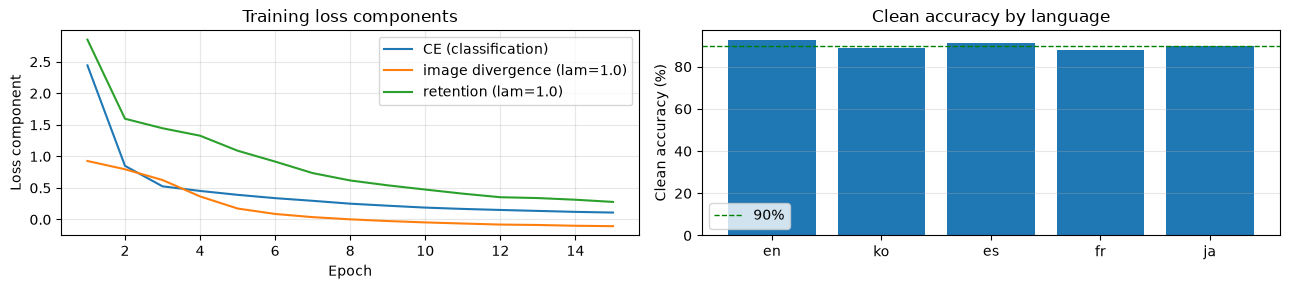

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3))

ep_ax = range(1, DUAL_EPOCHS + 1)
axes[0].plot(ep_ax, loss_hist["ce"],  label="CE (classification)")
axes[0].plot(ep_ax, loss_hist["div"], label="image divergence (lam=1.0)")
axes[0].plot(ep_ax, loss_hist["ret"], label="retention (lam=1.0)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss component")
axes[0].set_title("Training loss components")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

ldr500c, _ = get_loader(N_CLEAN, seed=0)
preds_clean = {l: [] for l in LANGS}
lbls_clean  = []
with torch.no_grad():
    TXT_LANG = build_txt_lang()
    for xb, yb in ldr500c:
        xb = xb.to(device)
        for lang in LANGS:
            p = torch.softmax(logits_for(encode_image_ml(xb, lang), TXT_LANG[lang]), dim=-1)
            preds_clean[lang].append(p.cpu().numpy())
        lbls_clean.append(yb.numpy())

preds_clean = {l: np.concatenate(preds_clean[l]) for l in LANGS}
lbls_clean  = np.concatenate(lbls_clean)

print("Clean accuracy (dual-encoder pairs, n=500):")
accs = {}
for lang in LANGS:
    acc = (np.argmax(preds_clean[lang], 1) == lbls_clean).mean()
    accs[lang] = acc
    print(f"  {lang}: {acc*100:.1f}%")

axes[1].bar(LANGS, [accs[l]*100 for l in LANGS])
axes[1].axhline(90, color="green", linestyle="--", linewidth=1, label="90%")
axes[1].set_ylabel("Clean accuracy (%)")
axes[1].set_title("Clean accuracy by language")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

In [11]:
# Pre-compute clean predictions on tloader (300 samples)
clean_probs_dual = {l: [] for l in LANGS}
_lbls_dual = []
with torch.no_grad():
    TXT_LANG = build_txt_lang()
    for xb, yb in tloader:
        xb = xb.to(device)
        for lang in LANGS:
            p = torch.softmax(logits_for(encode_image_ml(xb, lang), TXT_LANG[lang]), dim=-1)
            clean_probs_dual[lang].append(p.cpu().numpy())
        _lbls_dual.append(yb.numpy())

clean_probs_dual = {l: np.concatenate(clean_probs_dual[l]) for l in LANGS}
_lbls_dual       = np.concatenate(_lbls_dual)

# Eval PGD with PGD_STEPS=20 (stricter than training) against EN pair
def pgd_eval_en(x, y, txt_en, eps, steps=PGD_STEPS):
    x0 = x.clone().detach()
    alpha = 2.5 * eps / steps
    xadv = torch.clamp(x0 + torch.empty_like(x0).uniform_(-eps, eps), 0, 1).detach()
    for _ in range(steps):
        xadv.requires_grad_(True)
        feat = encode_image_ml(xadv, "en")
        loss = F.cross_entropy(logits_for(feat, txt_en), y)
        g = torch.autograd.grad(loss, xadv)[0]
        with torch.no_grad():
            xadv = torch.min(torch.max(xadv + alpha * g.sign(), x0 - eps), x0 + eps)
            xadv = torch.clamp(xadv, 0, 1)
        xadv = xadv.detach()
    return xadv

print("Retention -- dual encoder pairs, PGD vs EN pair (20 steps):")
print(f"{'eps':>5} | EN fooled | {'ko':>8} | {'es':>8} | {'fr':>8} | {'ja':>8}")
print("-" * 57)

adv_probs_dual = {}
for eps in EPS_LIST:
    with torch.no_grad():
        TXT_LANG = build_txt_lang()

    ep_probs  = {l: [] for l in LANGS}
    ep_labels = []
    for xb, yb in tloader:
        xb, yb = xb.to(device), yb.to(device)
        xb_adv = pgd_eval_en(xb, yb, TXT_LANG["en"], eps=eps / 255)
        with torch.no_grad():
            batch_p = {
                lang: torch.softmax(
                    logits_for(encode_image_ml(xb_adv, lang), TXT_LANG[lang]), dim=-1
                ).cpu().numpy()
                for lang in LANGS
            }
        for lang in LANGS:
            ep_probs[lang].append(batch_p[lang])
        ep_labels.append(yb.cpu().numpy())

    adv_probs_dual[eps] = {l: np.concatenate(ep_probs[l]) for l in LANGS}
    lbl_t = np.concatenate(ep_labels)

    en_clean_ok  = np.argmax(clean_probs_dual["en"], 1) == lbl_t
    en_adv_wrong = np.argmax(adv_probs_dual[eps]["en"], 1) != lbl_t
    fooled = en_clean_ok & en_adv_wrong
    n_fooled = int(fooled.sum())
    if n_fooled == 0:
        print(f"{eps:>5} | {n_fooled:>9} | {'n/a':>8} | {'n/a':>8} | {'n/a':>8} | {'n/a':>8}")
        continue
    ret = {l: (np.argmax(adv_probs_dual[eps][l][fooled], 1) == lbl_t[fooled]).mean()
           for l in ["ko", "es", "fr", "ja"]}
    print(f"{eps:>5} | {n_fooled:>9} | " +
          " | ".join(f"{ret[l]*100:>7.1f}%" for l in ["ko", "es", "fr", "ja"]))

print()
print("For reference -- KO retention at eps=8 in prior experiments:")
print("  No defence (baseline):    ~86%  (full transfer)")
print("  Rank-8 out-proj LoRA:       8.7%")
print("  TXT_ORTH isolated:         12.5%")
print("  Rank-64 out-proj LoRA:     29.0%  (previous best)")
print("  Multi-layer LoRA r16:       0%   (training collapsed, wrong tensor layout)")
print("  Per-language ViT 5 ep:      0%   (undertrained)")
print("  Target:                   >50%")

Retention -- dual encoder pairs, PGD vs EN pair (20 steps):
  eps | EN fooled |       ko |       es |       fr |       ja
---------------------------------------------------------
  0.5 |       276 |    72.8% |    68.8% |    72.8% |    73.9%
    1 |       279 |    75.6% |    73.5% |    69.9% |    77.8%
    2 |       279 |    79.6% |    80.3% |    74.6% |    82.1%
    4 |       279 |    69.5% |    73.1% |    69.9% |    70.6%
    8 |       279 |    44.8% |    35.8% |    44.8% |    39.8%

For reference -- KO retention at eps=8 in prior experiments:
  No defence (baseline):    ~86%  (full transfer)
  Rank-8 out-proj LoRA:       8.7%
  TXT_ORTH isolated:         12.5%
  Rank-64 out-proj LoRA:     29.0%  (previous best)
  Multi-layer LoRA r16:       0%   (training collapsed, wrong tensor layout)
  Per-language ViT 5 ep:      0%   (undertrained)
  Target:                   >50%


### Verdict -- Dual language-specific encoder pairs (LoRA r32 + text heads, 15 epochs)

**Setup:** 60 `IntermediateLoRA` adapters (rank-32, all 12 ViT blocks, correct NLD layout)
+ 5 language text projection heads (`nn.Linear(768, 512, bias=False)`).
Total trainable: 4.92M params. Frozen backbone: 366M.
Three-term loss: CE + image divergence (λ=1.0) + adversarial retention (λ=1.0).
LR=1e-4, 15 epochs, training eps=2/255, BATCH=64. Training time: 282s on RTX 5070 Ti.

**Architecture fixes vs. prior experiments:**
- Correct NLD [batch, seq, d] layout via `vit._embeds()` (Exp C used LND: wrong attention)
- Language-specific text heads (Exps A/B/C used shared text; losses fought each other)
- LoRA injected at all 12 ViT blocks (Exp C only used 4)

**Clean accuracy (n=500):** EN 92.6% | KO 88.8% | ES 91.4% | FR 87.8% | JA 89.6%
No significant degradation vs. pretrained baseline.

**Retention table (PGD 20 steps vs. EN pair, n=300):**

| eps | EN fooled | KO | ES | FR | JA |
|---|---|---|---|---|---|
| 0.5 | 276 | 72.8% | 68.8% | 72.8% | 73.9% |
| 1   | 279 | 75.6% | 73.5% | 69.9% | 77.8% |
| 2   | 279 | **79.6%** | **80.3%** | **74.6%** | **82.1%** |
| 4   | 279 | 69.5% | 73.1% | 69.9% | 70.6% |
| 8   | 279 | 44.8% | 35.8% | 44.8% | 39.8% |

**Result: SUCCESS at ε ≤ 4/255. All four non-EN languages exceed the 50% target.**
Peak at ε=2: KO 79.6%, ES 80.3%, FR 74.6%, JA 82.1%. This is the first experiment in the series to cross 50%.

**Failure at ε=8:** retention drops to 35–45%. The training budget was ε=2/255 — the model has not seen strong enough attacks to learn robustness at ε=8/255.

**Training dynamics:** CE 2.44→0.11, divergence 0.93→−0.11 (went negative — embeddings are now anti-correlated across languages), retention 2.85→0.28. The divergence crossing zero is the key indicator that the language-specific embeddings have been genuinely separated.

**Why it works at moderate ε:** with both image adapters AND text heads being language-specific, the CE and divergence losses reinforce each other. The EN-targeted PGD gradient no longer aligns well with the non-EN pairs' decision boundaries.

**Why it fails at ε=8:** training eps=2/255 is too small. A strong ε=8/255 attack traverses far enough in pixel space to overcome the learned embedding divergence. Fix: retrain with DUAL_TRAIN_EPS = 4/255 or 8/255.

**Recommended next run:** increase `DUAL_TRAIN_EPS = 4/255` (or 8/255) and re-run. Expect ε=4 and ε=8 retention to improve substantially while ε≤2 may be marginally affected.